# KLDM+ loss vs time diagnostic

This notebook measures average graph loss on a fixed time grid for a trained KLDM+ checkpoint.

Why this matters:
- if the loss curve is nearly flat over time, loss-aware time sampling is unlikely to help much
- if the loss curve is strongly uneven, loss-aware sampling is much more promising

Important:
- for a meaningful result, use a trained checkpoint
- an untrained model can be evaluated too, but that mostly reflects random initialization rather than learned difficulty over time


In [1]:
from pathlib import Path
import sys
import json
import math

import matplotlib.pyplot as plt
import pandas as pd
import torch
import yaml
from torch.utils.data import DataLoader, Subset
from torch_scatter import scatter_mean

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'src').exists():
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError('Could not find repo root with a src/ directory.')

SRC_ROOT = REPO_ROOT / 'src'
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from kldmPlus.data import CSPTask, resolve_data_root
from kldmPlus.utils.model_loader import build_model, load_checkpoint
from kldmPlus.utils.time import make_times

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device={device}')


MODELS_PROJECT_ROOT: /workspace/.venv/lib/python3.11/site-packages/mattergen
device=cpu


In [ ]:
# Edit these before running.
CONFIG_PATH = REPO_ROOT / 'configs' / 'kldm_plus' / 'mp_20' / 'mp20_lattice_eps_em.yaml'
CHECKPOINT_PATH = "/workspace/artifacts/HPC/checkpoints/epoch_1500.pt"

PREFER_EMA_WEIGHTS = True
LOWER_BOUND = 1e-3
NUM_TIME_POINTS =40
MAX_VAL_GRAPHS = 128
BATCH_LIMIT = 64
REPEATS_PER_TIME = 1

if CHECKPOINT_PATH is None:
    raise ValueError('Set CHECKPOINT_PATH to a trained KLDM+ checkpoint before running this notebook.')

CHECKPOINT_PATH = Path(CHECKPOINT_PATH).expanduser().resolve()
CONFIG_PATH = Path(CONFIG_PATH).expanduser().resolve()

print('config   =', CONFIG_PATH)
print('checkpoint =', CHECKPOINT_PATH)


config   = /workspace/configs/kldm_plus/mp_20/mp20_lattice_eps_em.yaml
checkpoint = /workspace/artifacts/HPC/checkpoints/epoch_600.pt


In [3]:
with CONFIG_PATH.open('r', encoding='utf-8') as handle:
    config = yaml.safe_load(handle) or {}

model = build_model(config=config, device=device)
checkpoint = load_checkpoint(
    checkpoint_path=CHECKPOINT_PATH,
    model=model,
    device=device,
    prefer_ema_weights=PREFER_EMA_WEIGHTS,
)
model.eval()

dataset_cfg = dict(config['dataset'])
model_cfg = dict(config['model'])
validation_cfg = dict(config['validation'])

task = CSPTask(
    dataset_name=str(dataset_cfg['name']),
    lattice_parameterization=str(model_cfg['lattice_parameterization']),
)

root = resolve_data_root(dataset_cfg['root'])
batch_size = int(dataset_cfg['batch_size'])
num_workers = int(dataset_cfg['num_workers'])
pin_memory = bool(dataset_cfg['pin_memory'])

val_dataset_full = task.fit_dataset(root=root, split='val', download=True)
subset_size = validation_cfg.get('subset_size')
subset_seed = int(validation_cfg.get('subset_seed', 123))

if subset_size is not None and subset_size > 0 and subset_size < len(val_dataset_full):
    generator = torch.Generator().manual_seed(subset_seed)
    subset_indices = torch.randperm(len(val_dataset_full), generator=generator)[:subset_size].tolist()
    val_dataset = Subset(val_dataset_full, subset_indices)
else:
    val_dataset = val_dataset_full

if MAX_VAL_GRAPHS is not None and MAX_VAL_GRAPHS > 0:
    max_graphs = min(int(MAX_VAL_GRAPHS), len(val_dataset))
    val_dataset = Subset(val_dataset, list(range(max_graphs)))

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
    collate_fn=val_dataset_full.collate_fn,
)

print('loaded checkpoint epoch =', checkpoint.get('epoch'))
print('validation graphs used  =', len(val_dataset))


loaded checkpoint epoch = 600
validation graphs used  = 128


In [4]:
@torch.no_grad()
def graph_losses_at_time(model, batch, t_scalar):
    batch = batch.to(device)
    t_graph = torch.full(
        (batch.num_graphs, 1),
        float(t_scalar),
        device=batch.pos.device,
        dtype=batch.pos.dtype,
    )
    times = make_times(batch, t_graph)

    noisy, targets = model.algorithm1_training_targets(batch=batch, times=times)
    v_t, f_t, l_t = noisy
    target_v, target_l = targets

    preds = model.score_network(
        t=times.graph,
        pos=f_t,
        v=v_t,
        h=batch.atomic_numbers,
        l=l_t,
        node_index=batch.batch,
        edge_node_index=batch.edge_node_index,
    )

    loss_l_graph = model.mse_loss_per_sample(preds['l'], target_l)
    loss_v_node = model.mse_loss_per_sample(preds['v'], target_v)
    loss_v_graph = scatter_mean(loss_v_node, index=batch.batch, dim=0)
    loss_graph = loss_v_graph + loss_l_graph

    return {
        'loss_graph': loss_graph.detach().cpu(),
        'loss_v_graph': loss_v_graph.detach().cpu(),
        'loss_l_graph': loss_l_graph.detach().cpu(),
    }


@torch.no_grad()
def estimate_loss_curve(model, loader, time_grid, repeats_per_time=1, batch_limit=None):
    rows = []
    for t_scalar in time_grid.tolist():
        graph_losses = []
        v_losses = []
        l_losses = []

        for _ in range(int(repeats_per_time)):
            for batch_idx, batch in enumerate(loader):
                if batch_limit is not None and batch_idx >= int(batch_limit):
                    break

                losses = graph_losses_at_time(model, batch, t_scalar)
                graph_losses.append(losses['loss_graph'])
                v_losses.append(losses['loss_v_graph'])
                l_losses.append(losses['loss_l_graph'])

        graph_losses = torch.cat(graph_losses)
        v_losses = torch.cat(v_losses)
        l_losses = torch.cat(l_losses)

        rows.append({
            't': float(t_scalar),
            'loss_graph_mean': float(graph_losses.mean()),
            'loss_graph_std': float(graph_losses.std(unbiased=False)),
            'loss_v_mean': float(v_losses.mean()),
            'loss_l_mean': float(l_losses.mean()),
        })

    return pd.DataFrame(rows)


In [5]:
time_grid = torch.linspace(LOWER_BOUND, 1.0, NUM_TIME_POINTS, dtype=torch.float64)
curve = estimate_loss_curve(
    model=model,
    loader=val_loader,
    time_grid=time_grid,
    repeats_per_time=REPEATS_PER_TIME,
    batch_limit=BATCH_LIMIT,
)
curve.head()


,t,loss_graph_mean,loss_graph_std,loss_v_mean,loss_l_mean
0,0.001000,0.976770,0.565294,0.397470,0.579299
1,0.026615,0.396733,0.315221,0.361917,0.034816
2,0.052231,0.314409,0.286583,0.300471,0.013938
3,0.077846,0.271806,0.270877,0.265086,0.006720
4,0.103462,0.222320,0.232675,0.217730,0.004590


In [6]:
summary = pd.DataFrame([
    {
        'metric': 'loss_graph',
        'mean_over_time': curve['loss_graph_mean'].mean(),
        'std_over_time': curve['loss_graph_mean'].std(ddof=0),
        'flatness_cv': curve['loss_graph_mean'].std(ddof=0) / max(curve['loss_graph_mean'].mean(), 1e-12),
    },
    {
        'metric': 'loss_v',
        'mean_over_time': curve['loss_v_mean'].mean(),
        'std_over_time': curve['loss_v_mean'].std(ddof=0),
        'flatness_cv': curve['loss_v_mean'].std(ddof=0) / max(curve['loss_v_mean'].mean(), 1e-12),
    },
    {
        'metric': 'loss_l',
        'mean_over_time': curve['loss_l_mean'].mean(),
        'std_over_time': curve['loss_l_mean'].std(ddof=0),
        'flatness_cv': curve['loss_l_mean'].std(ddof=0) / max(curve['loss_l_mean'].mean(), 1e-12),
    },
])

summary


,metric,mean_over_time,std_over_time,flatness_cv
0,loss_graph,0.252590,0.189271,0.749320
1,loss_v,0.235769,0.151167,0.641166
2,loss_l,0.016821,0.090249,5.365250


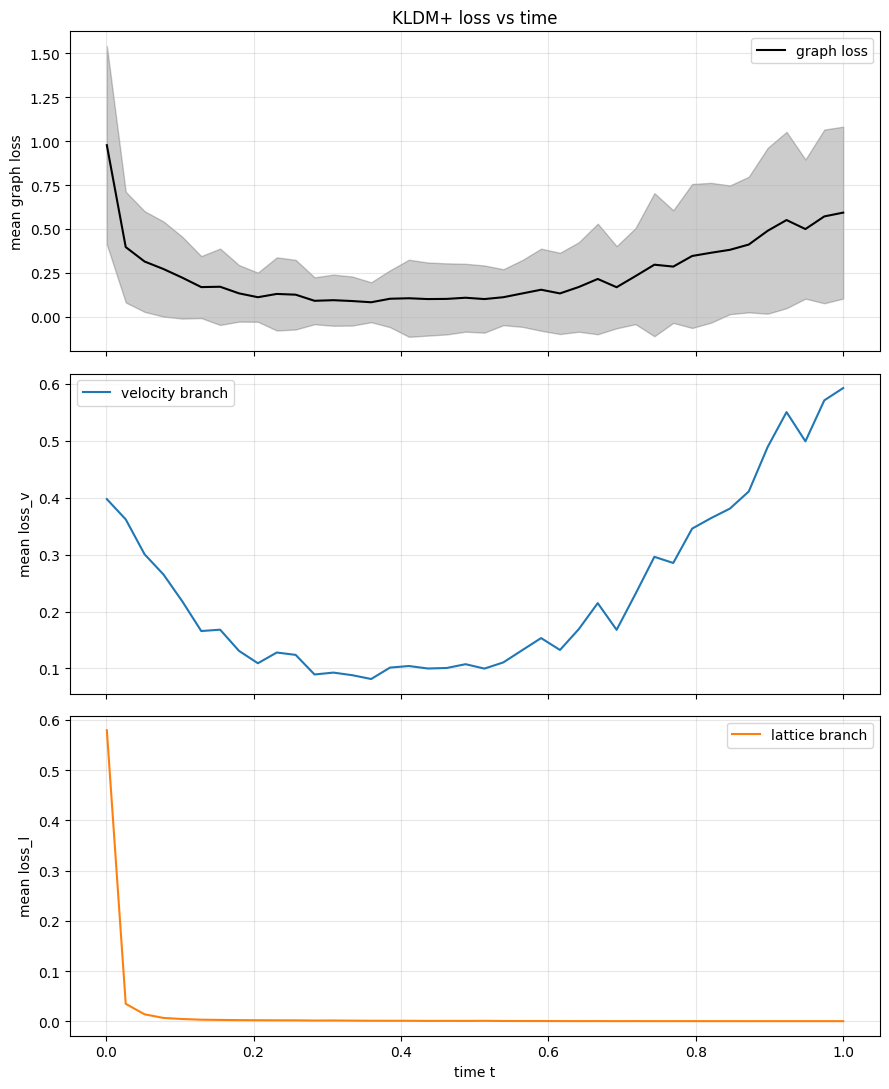

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(9, 11), sharex=True)

axes[0].plot(curve['t'], curve['loss_graph_mean'], label='graph loss', color='black')
axes[0].fill_between(
    curve['t'],
    curve['loss_graph_mean'] - curve['loss_graph_std'],
    curve['loss_graph_mean'] + curve['loss_graph_std'],
    alpha=0.2,
    color='black',
)
axes[0].set_ylabel('mean graph loss')
axes[0].set_title('KLDM+ loss vs time')
axes[0].grid(alpha=0.3)

axes[1].plot(curve['t'], curve['loss_v_mean'], label='velocity branch', color='tab:blue')
axes[1].set_ylabel('mean loss_v')
axes[1].grid(alpha=0.3)

axes[2].plot(curve['t'], curve['loss_l_mean'], label='lattice branch', color='tab:orange')
axes[2].set_ylabel('mean loss_l')
axes[2].set_xlabel('time t')
axes[2].grid(alpha=0.3)

for ax in axes:
    ax.legend()

plt.tight_layout()
plt.show()


## How to read the result

- If `loss_graph_mean` is close to flat across time, loss-aware time sampling is less compelling.
- If it has clear peaks or strongly uneven regions, those are the parts of the diffusion interval where adaptive sampling is most likely to help.
- If only `loss_v_mean` is uneven while `loss_l_mean` is flat, the case for adaptive sampling is mostly about the TDM branch.
- If both are uneven, then adaptive sampling is more broadly justified.
